# Projet Morel : Scoring pour Service Solution Client — Prédiction & Export

# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
import gc
import json
import joblib
import mlflow
import mlflow.sklearn

import time
import numpy as np
import onnx
import onnxruntime as ort
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType, StringTensorType
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

from datetime import datetime


c:\Users\15GIRAV\Moi\Boulot\OpenClassrooms\P8_Confirmez_vos_competences_en_MLOPS_partie_2_2\.venv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
from pathlib import Path
from sklearn.pipeline import Pipeline as SkPipeline
import onnxruntime as ort
import numpy as np
import onnx
from skl2onnx import to_onnx, update_registered_converter
from skl2onnx.common.data_types import FloatTensorType, StringTensorType
from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost
from xgboost import XGBClassifier
import re

In [28]:
import time
import re
import numpy as np
import onnxruntime as ort
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

# MLflow — configuration

In [2]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Même expérience que le notebook d'entraînement, pour garder tout l'historique
# du projet comparable au même endroit dans l'UI MLflow.
EXPERIMENT_NAME = "Projet_Morel_Scoring_BERA_M"
mlflow.set_experiment(EXPERIMENT_NAME)

# Sécurité : on ferme de force toute session restée ouverte par erreur
mlflow.end_run()

print(f"✅ Configuration MLflow initialisée (expérience : '{EXPERIMENT_NAME}').")


✅ Configuration MLflow initialisée (expérience : 'Projet_Morel_Scoring_BERA_M').


**Toujours pas d'autologging.** Pour la même raison que dans le notebook d'entraînement :
`mlflow.sklearn.autolog()` combiné à `RandomizedSearchCV(n_jobs=-1)` est une cause connue de
`BrokenProcessPool` sous Windows. Tout est loggué manuellement ci-dessous.


# Chargement des données et du modèle de production actuel

In [3]:
df_final_model_enriched = pd.read_csv('df_final_model_enriched.csv', low_memory=False)
df_final_model_enriched.head()


,Unnamed: 0,Famille_0_N_signature_2,Famille_6_N_signature_3,Panier_Moyen_N_signature_2,Famille_16_N_signature_1,Famille_16_N_signature_3,Famille_10_N_signature_4,Turnover_N_signature_4,Turnover_N_signature_2,Famille_9_N_signature_2,...,customer_value_score,branche,clp_contrat_ap_stat,annees_depuis_1ere_facture,annees_depuis_dernier_achat,code_departemental,pot_40_calc,GrandCompte,NOTE_COFACE,_EC
0,0,84.0,0.0,0.00,2.0,4.0,18.0,3958.370117,7023.759766,2.0,...,69.0,4903.0,BK,21.0,0.0,22.0,18421.0,True,6.0,87.7
1,1,1.0,1.0,62.73,9.0,3.0,21.0,21478.429688,7214.049805,3.0,...,96.0,4078.0,BK,21.0,0.0,82.0,18421.0,True,4.0,9.2
2,2,59.0,0.0,0.00,35.0,5.0,32.0,5500.729980,12811.910156,10.0,...,88.0,5237.0,BK,21.0,0.0,22.0,7875.0,True,7.0,6.3
3,3,9.0,0.0,81.47,0.0,0.0,0.0,1327.309937,5540.299805,3.0,...,80.0,3001.0,AE,21.0,0.0,24.0,7143.0,True,3.0,47.9
4,4,8.0,0.0,0.00,0.0,0.0,13.0,1128.189941,2259.689941,6.0,...,47.0,3003.0,NaN,21.0,0.0,83.0,5357.0,True,9.0,0.0


In [4]:
df_final_model_enriched = df_final_model_enriched.drop(columns=['Unnamed: 0'])
df_final_model_enriched.head()

,Famille_0_N_signature_2,Famille_6_N_signature_3,Panier_Moyen_N_signature_2,Famille_16_N_signature_1,Famille_16_N_signature_3,Famille_10_N_signature_4,Turnover_N_signature_4,Turnover_N_signature_2,Famille_9_N_signature_2,Famille_14_N_signature_4,...,customer_value_score,branche,clp_contrat_ap_stat,annees_depuis_1ere_facture,annees_depuis_dernier_achat,code_departemental,pot_40_calc,GrandCompte,NOTE_COFACE,_EC
0,84.0,0.0,0.00,2.0,4.0,18.0,3958.370117,7023.759766,2.0,0.0,...,69.0,4903.0,BK,21.0,0.0,22.0,18421.0,True,6.0,87.7
1,1.0,1.0,62.73,9.0,3.0,21.0,21478.429688,7214.049805,3.0,0.0,...,96.0,4078.0,BK,21.0,0.0,82.0,18421.0,True,4.0,9.2
2,59.0,0.0,0.00,35.0,5.0,32.0,5500.729980,12811.910156,10.0,0.0,...,88.0,5237.0,BK,21.0,0.0,22.0,7875.0,True,7.0,6.3
3,9.0,0.0,81.47,0.0,0.0,0.0,1327.309937,5540.299805,3.0,0.0,...,80.0,3001.0,AE,21.0,0.0,24.0,7143.0,True,3.0,47.9
4,8.0,0.0,0.00,0.0,0.0,13.0,1128.189941,2259.689941,6.0,3.0,...,47.0,3003.0,NaN,21.0,0.0,83.0,5357.0,True,9.0,0.0


In [5]:
# On charge le modèle depuis le registre MLflow (source de vérité pour la production),
# et non depuis un fichier .pkl local qui pourrait être désynchronisé.
model_uri = "models:/XGBoost_BERA_Pipeline/latest"
best_pipeline = mlflow.sklearn.load_model(model_uri)

print("✅ Modèle de production chargé depuis MLflow :", model_uri)


✅ Modèle de production chargé depuis MLflow : models:/XGBoost_BERA_Pipeline/latest


# Préparation des features (identique au notebook d'entraînement)

In [6]:
# Seules les colonnes réellement présentes dans le CSV et non-pertinentes pour le modèle
# sont exclues : identifiants, cible, et score externe NOTE_COFACE.
colonnes_a_exclure = ["code_client", "compagny", "is_BERA_M", "NOTE_COFACE"]
features_model = [col for col in df_final_model_enriched.columns if col not in colonnes_a_exclure]

X = df_final_model_enriched[features_model].copy()
y = df_final_model_enriched["is_BERA_M"].astype(int)

colonnes_cat = [col for col in X.columns if X[col].dtype == 'object' or X[col].dtype.name == 'category']
for col in colonnes_cat:
    X[col] = X[col].astype('category')

# Même random_state que le notebook d'entraînement : split reproductible et cohérent
# avec celui utilisé pour évaluer le modèle en production actuel.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Structure de l'entraînement (X_train) : {X_train.shape}")
print(f"Structure du test (X_test) : {X_test.shape}")


Structure de l'entraînement (X_train) : (145649, 83)
Structure du test (X_test) : (36413, 83)


# Feature importance

C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_25488\759821897.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Importance", y="Feature", data=df_importances, palette="Blues_r")


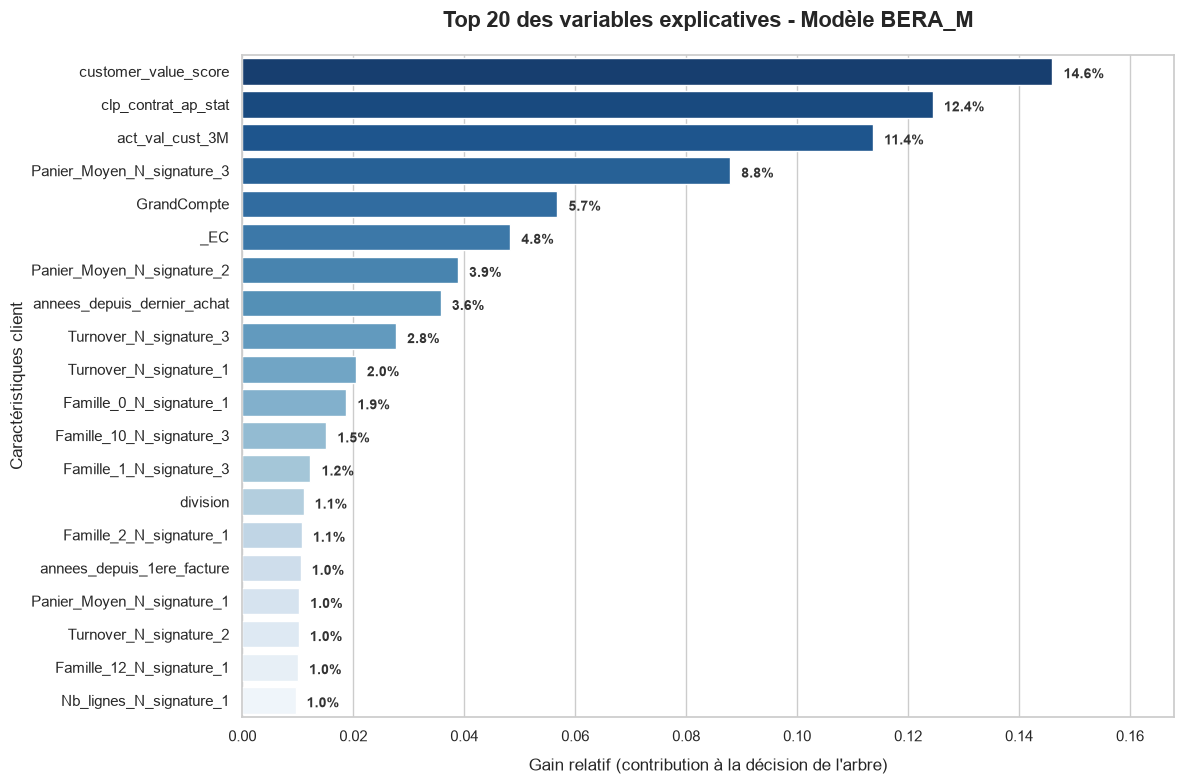

In [7]:
model_xgb = best_pipeline.named_steps["xgb"]
importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

top_n = 20
df_importances = importances.head(top_n).reset_index()
df_importances.columns = ['Feature', 'Importance']

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="Importance", y="Feature", data=df_importances, palette="Blues_r")

for p in ax.patches:
    width = p.get_width()
    if width > 0.001:
        ax.text(width + 0.002, p.get_y() + p.get_height() / 2 + 0.1,
                f'{width * 100:.1f}%', ha="left", va="center", fontsize=10, fontweight='bold', color='#333333')

plt.title(f"Top {top_n} des variables explicatives - Modèle BERA_M", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Gain relatif (contribution à la décision de l'arbre)", fontsize=12, labelpad=10)
plt.ylabel("Caractéristiques client", fontsize=12)
plt.xlim(0, df_importances['Importance'].max() * 1.15)
plt.tight_layout()
plt.show()


Une grande partie des features a une importance inférieure à 1%. On va tester un modèle réduit à ces 20 variables principales — **à condition de vérifier que ça ne dégrade pas significativement la performance** (voir la comparaison d'AUC après le réentraînement, plus bas).

# Réduction des variables et réentraînement

In [8]:
features_model_epure = df_importances["Feature"].tolist()
colonnes_cat_epure = [col for col in colonnes_cat if col in features_model_epure]

X_train_epure = X_train[features_model_epure].copy()
X_test_epure = X_test[features_model_epure].copy()

print(f"📉 Nombre de variables initiales : {len(X_train.columns)}")
print(f"🎯 Nombre de variables conservées (Top {top_n}) : {len(features_model_epure)}")
print(f"🔤 Dont variables catégorielles à encoder : {len(colonnes_cat_epure)} {colonnes_cat_epure}")


📉 Nombre de variables initiales : 83
🎯 Nombre de variables conservées (Top 20) : 20
🔤 Dont variables catégorielles à encoder : 0 []


In [9]:
# Hypothèses de coût métier (mêmes valeurs que le notebook d'entraînement)
cout_appel_inutile = 20    # coût d'un appel inutile (faux positif)
gain_contrat_rate = 1500   # manque à gagner d'un client manqué (faux négatif)


In [10]:
# Grille et schéma de validation croisée définis ICI pour que ce notebook soit autonome
# (ne dépend plus d'un état de kernel laissé par le notebook d'entraînement).
param_dist_xgb = {
    "smote__sampling_strategy": [0.25, 0.5, "auto"],
    "xgb__n_estimators": [100, 150, 200],
    "xgb__max_depth": [3, 4, 5, 6],
    "xgb__learning_rate": [0.05, 0.1, 0.2],
}

cv_stratifie = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [11]:
# 1) Vérifie la cohérence AVANT d'entraîner
print("Nb features X_train_epure :", X_train_epure.shape[1])
print("features_model_epure      :", len(features_model_epure))
print("colonnes_cat_epure        :", colonnes_cat_epure)

# 2) Recalcule colonnes_cat_epure DEPUIS X_train_epure (pas depuis X_train !)
from pandas.api.types import is_string_dtype, is_categorical_dtype

colonnes_cat_epure = [
    c for c in X_train_epure.columns
    if X_train_epure[c].dtype == 'object'
    or is_string_dtype(X_train_epure[c])
    or is_categorical_dtype(X_train_epure[c])
]
print("Colonnes cat retenues dans le Top20 :", colonnes_cat_epure)

# 3) Construis le pipeline dans une FONCTION → instance neuve à chaque appel
def build_xgb_pipeline_epure():
    return Pipeline([
        ("encoder", TargetEncoder(
            cols=colonnes_cat_epure,
            handle_missing="value",
            handle_unknown="value",
            smoothing=10.0,
        )),
        ("imputer", SimpleImputer(strategy='median')),
        ("smote", SMOTE(random_state=42)),
        ("xgb", XGBClassifier(random_state=42, n_jobs=1, eval_metric="logloss")),
    ])

random_search_xgb_epure = RandomizedSearchCV(
    estimator=build_xgb_pipeline_epure(),   # ← instance fraîche
    param_distributions=param_dist_xgb,
    n_iter=15, scoring="roc_auc", cv=cv_stratifie,
    random_state=42, n_jobs=1, verbose=1,
)

Nb features X_train_epure : 20
features_model_epure      : 20
colonnes_cat_epure        : []
Colonnes cat retenues dans le Top20 : ['clp_contrat_ap_stat', 'division']


C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_25488\402991069.py:13: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or is_categorical_dtype(X_train_epure[c])


In [12]:
X_test_epure = X_test_epure[X_train_epure.columns]
assert list(X_train_epure.columns) == list(X_test_epure.columns)

In [13]:
if not colonnes_cat_epure:
    # pas d'encodage nécessaire, on saute l'étape
    steps = [("imputer", SimpleImputer(strategy='median')),
             ("smote", SMOTE(random_state=42)),
             ("xgb", XGBClassifier(random_state=42, n_jobs=1, eval_metric="logloss"))]
else:
    steps = [("encoder", TargetEncoder(cols=colonnes_cat_epure, handle_missing="value",
                                        handle_unknown="value", smoothing=10.0))] + [...]

In [14]:
os.makedirs("../models", exist_ok=True)

print("🚀 Réentraînement du pipeline épuré (Top 20 features)...")

preprocessor = ColumnTransformer(transformers=[("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), colonnes_cat_epure)], remainder="passthrough")

new_pipeline_xgb = Pipeline([
    ("encoder", preprocessor),
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(random_state=42, n_jobs=1, eval_metric="logloss"))])

with mlflow.start_run(run_name="XGBoost_Pipeline_Epure_Top20") as run_epure:

    # ------------------------------------------------------------
    # 1. Entraînement
    # ------------------------------------------------------------
    random_search_xgb_epure = RandomizedSearchCV(
        estimator=new_pipeline_xgb,
        param_distributions=param_dist_xgb,
        n_iter=15, scoring="roc_auc", cv=cv_stratifie,
        random_state=42, n_jobs=1, verbose=1,
    )
    random_search_xgb_epure.fit(X_train_epure, y_train)
    best_pipeline_epure = random_search_xgb_epure.best_estimator_

    for param_name, param_value in random_search_xgb_epure.best_params_.items():
        mlflow.log_param(param_name, param_value)
    mlflow.log_param("nombre_features", len(features_model_epure))

    # ------------------------------------------------------------
    # 2. Évaluation + seuil de décision optimal (coût métier)
    # ------------------------------------------------------------
    y_score_epure = best_pipeline_epure.predict_proba(X_test_epure)[:, 1]
    auc_test_epure = roc_auc_score(y_test, y_score_epure)

    seuils_testes = np.arange(0.05, 0.96, 0.01)
    couts = []
    for seuil in seuils_testes:
        y_pred_s = (y_score_epure >= seuil).astype(int)
        cm_s = confusion_matrix(y_test, y_pred_s)
        fp_s = cm_s[0, 1] if cm_s.shape == (2, 2) else 0
        fn_s = cm_s[1, 0] if cm_s.shape == (2, 2) else 0
        couts.append(fp_s * cout_appel_inutile + fn_s * gain_contrat_rate)
    couts = np.array(couts)
    meilleur_seuil_epure = float(seuils_testes[np.argmin(couts)])
    cout_min_epure = float(couts.min())

    mlflow.log_metric("auc_test", auc_test_epure)
    mlflow.log_metric("cout_total_erreurs_euros", cout_min_epure)
    mlflow.log_param("seuil_decision_optimal", meilleur_seuil_epure)

    print(f"✨ AUC test (modèle épuré) : {auc_test_epure:.4f}")
    print(f"🎯 Seuil optimal : {meilleur_seuil_epure:.2f} | Coût min : {cout_min_epure:.0f} €")

    # ------------------------------------------------------------
    # 3. Sauvegarde — DANS le run actif
    # ------------------------------------------------------------
    mlflow.sklearn.log_model(
        sk_model=best_pipeline_epure,
        name="pipeline_model_epure",
        serialization_format="cloudpickle",
        registered_model_name="XGBoost_BERA_Pipeline_Epure",
    )
    joblib.dump(best_pipeline_epure, "../models/best_pipeline_xgboost_epure.pkl")

    df_pred_epure = pd.DataFrame({
        'True_Label': y_test.values,
        'Predicted_Label': (y_score_epure >= meilleur_seuil_epure).astype(int),
        'Probability_Class_1': y_score_epure,
    })
    file_epure = "predictions_epure_model.csv"
    df_pred_epure.to_csv(file_epure, index=False)
    mlflow.log_artifact(file_epure, artifact_path="predictions")
    os.remove(file_epure)

    run_id_epure = run_epure.info.run_id

print(f"\n✅ Run MLflow (modèle épuré) : {run_id_epure}")


🚀 Réentraînement du pipeline épuré (Top 20 features)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


2026/09/09 15:43:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✨ AUC test (modèle épuré) : 0.9899
🎯 Seuil optimal : 0.07 | Coût min : 39180 €

✅ Run MLflow (modèle épuré) : c7f7a92b55334bd99df8d95af21bcf97


Registered model 'XGBoost_BERA_Pipeline_Epure' already exists. Creating a new version of this model...
Created version '7' of model 'XGBoost_BERA_Pipeline_Epure'.


# Passage en production : comparaison avant de décider

Le modèle épuré n'est adopté que s'il n'est **pas significativement moins bon** que le modèle
complet déjà en production (on tolère jusqu'à 1 point d'AUC de moins, en échange d'un modèle plus
simple avec 4x moins de variables). Sinon, on garde le modèle complet.


In [15]:
# Récupération de l'AUC du modèle complet actuellement en production, directement
# depuis l'historique MLflow (pas besoin de le réentraîner ni de le recharger en mémoire).
runs_original = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    filter_string="tags.mlflow.runName = 'XGBoost_Final_Optimise'",
    order_by=["start_time DESC"],
)

TOLERANCE_AUC = 0.01

if not runs_original.empty and "metrics.auc_test" in runs_original.columns:
    auc_original = runs_original.iloc[0]["metrics.auc_test"]
    print(f"AUC modèle complet ({len(X_train.columns)} features) : {auc_original:.4f}")
    print(f"AUC modèle épuré ({len(features_model_epure)} features)  : {auc_test_epure:.4f}")
    print(f"Écart : {auc_test_epure - auc_original:+.4f}")

    adopter_modele_epure = (auc_test_epure >= auc_original - TOLERANCE_AUC)
else:
    print("⚠️ Impossible de retrouver le run du modèle complet dans MLflow — "
          "on adopte le modèle épuré par défaut, à vérifier manuellement.")
    adopter_modele_epure = True

if adopter_modele_epure:
    print("\n✅ Décision : on passe en production le modèle ÉPURÉ (plus simple, performance comparable).")
    best_pipeline_prod = best_pipeline_epure
    features_model_prod = features_model_epure
    colonnes_cat_prod = colonnes_cat_epure
    seuil_production = meilleur_seuil_epure
else:
    print("\n✅ Décision : on GARDE le modèle complet (le modèle épuré perd trop d'AUC).")
    best_pipeline_prod = best_pipeline
    features_model_prod = features_model
    colonnes_cat_prod = colonnes_cat
    seuil_production = 0.5


AUC modèle complet (83 features) : 0.9897
AUC modèle épuré (20 features)  : 0.9899
Écart : +0.0002

✅ Décision : on passe en production le modèle ÉPURÉ (plus simple, performance comparable).


In [16]:
# Assure-toi que le dossier existe
os.makedirs("../models", exist_ok=True)

# Sauvegarde le VRAI modèle retenu pour la prod
joblib.dump(best_pipeline_prod, "../models/best_pipeline_production.joblib")
print("💾 Modèle de production sauvegardé avec succès dans '../models/best_pipeline_production.joblib'")

💾 Modèle de production sauvegardé avec succès dans '../models/best_pipeline_production.joblib'


# Scoring des prospects

**Fait avec le modèle finalement retenu pour la production** (`best_pipeline_prod`), pas avec
un modèle intermédiaire — c'est le principal bug corrigé par rapport à la version précédente.


In [17]:
print("🎯 Isolation de la population cible (prospects non-signataires)...")

df_prospects = df_final_model_enriched[df_final_model_enriched["is_BERA_M"] == 0].copy()
X_prospects = df_prospects[features_model_prod].copy()

for col in colonnes_cat_prod:
    X_prospects[col] = X_prospects[col].astype('category')

print("🔮 Calcul des probabilités d'achat (scoring)...")
df_prospects["Score_Appetence_BERA_M"] = best_pipeline_prod.predict_proba(X_prospects)[:, 1]

# Bornes de priorité calées sur le seuil optimal métier retenu, pas des valeurs arbitraires.
seuil_bas = seuil_production * 0.6
seuil_haut = seuil_production * 1.3

def assigner_priorite(score):
    if score >= seuil_haut:
        return "1 - TOP PRIORITÉ"
    elif score >= seuil_bas:
        return "2 - PRIORITÉ MOYENNE"
    else:
        return "3 - BASSE PRIORITÉ"

df_prospects["Priorite_Appel"] = df_prospects["Score_Appetence_BERA_M"].apply(assigner_priorite)

colonnes_export = [
    "code_client", "compagny", "division", "branche",
    "NOTE_COFACE", "_EC", "Score_Appetence_BERA_M", "Priorite_Appel",
]

livrable_commercial = df_prospects[colonnes_export].sort_values(
    by="Score_Appetence_BERA_M", ascending=False
)

print(f"\n✅ Traitement terminé. Nombre de prospects scorés : {livrable_commercial.shape[0]}")
print("\n--- APERÇU DES 10 MEILLEURS PROSPECTS À CIBLER ---")
print(livrable_commercial.head(10).to_string(index=False))


🎯 Isolation de la population cible (prospects non-signataires)...
🔮 Calcul des probabilités d'achat (scoring)...

✅ Traitement terminé. Nombre de prospects scorés : 180830

--- APERÇU DES 10 MEILLEURS PROSPECTS À CIBLER ---
 code_client compagny division  branche  NOTE_COFACE  _EC  Score_Appetence_BERA_M   Priorite_Appel
1551439000.0     FR15   15-010   1110.0          6.0  0.0                0.955639 1 - TOP PRIORITÉ
1526870800.0     FR15   15-000   5999.0          8.0 50.0                0.937036 1 - TOP PRIORITÉ
1531486000.0     FR15   15-011   2000.0          6.0  0.0                0.899538 1 - TOP PRIORITÉ
1562271700.0     FR15   15-001   4021.0          4.0  0.3                0.895498 1 - TOP PRIORITÉ
1512979700.0     FR15   15-010   1110.0          8.0 52.0                0.885730 1 - TOP PRIORITÉ
1593120000.0     FR15   15-001   4509.0          7.0 27.3                0.870623 1 - TOP PRIORITÉ
1554854900.0     FR15   15-011   3300.0          9.0 91.8                0.853952 1

In [18]:
# Export réel sur disque
nom_fichier_export = f"livrable_commercial_scoring_BERA_M_{datetime.now():%Y%m%d}.csv"
livrable_commercial.to_csv(nom_fichier_export, index=False)
print(f"💾 Livrable exporté : '{nom_fichier_export}'")


💾 Livrable exporté : 'livrable_commercial_scoring_BERA_M_20260909.csv'


# Vérification finale

In [19]:
# On sauvegarde aussi la liste de features + le seuil de production en artefact JSON
config_production = {
    "features_model": features_model_prod,
    "colonnes_cat": colonnes_cat_prod,
    "seuil_production": seuil_production,
}
with open("../models/config_production.json", "w", encoding="utf-8") as f:
    json.dump(config_production, f, ensure_ascii=False, indent=2)

print("💾 Configuration de production sauvegardée : '../models/config_production.json'")


💾 Configuration de production sauvegardée : '../models/config_production.json'


In [20]:
print(json.dumps(config_production, ensure_ascii=False, indent=2))

{
  "features_model": [
    "customer_value_score",
    "clp_contrat_ap_stat",
    "act_val_cust_3M",
    "Panier_Moyen_N_signature_3",
    "GrandCompte",
    "_EC",
    "Panier_Moyen_N_signature_2",
    "annees_depuis_dernier_achat",
    "Turnover_N_signature_3",
    "Turnover_N_signature_1",
    "Famille_0_N_signature_1",
    "Famille_10_N_signature_3",
    "Famille_1_N_signature_3",
    "division",
    "Famille_2_N_signature_1",
    "annees_depuis_1ere_facture",
    "Panier_Moyen_N_signature_1",
    "Turnover_N_signature_2",
    "Famille_12_N_signature_1",
    "Nb_lignes_N_signature_1"
  ],
  "colonnes_cat": [
    "clp_contrat_ap_stat",
    "division"
  ],
  "seuil_production": 0.07
}


In [21]:
X_train_epure.info()

<class 'pandas.DataFrame'>
Index: 145649 entries, 165420 to 83410
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   customer_value_score         72168 non-null   float64
 1   clp_contrat_ap_stat          28851 non-null   str    
 2   act_val_cust_3M              145649 non-null  bool   
 3   Panier_Moyen_N_signature_3   145649 non-null  float64
 4   GrandCompte                  145649 non-null  bool   
 5   _EC                          145649 non-null  float64
 6   Panier_Moyen_N_signature_2   145649 non-null  float64
 7   annees_depuis_dernier_achat  145649 non-null  float64
 8   Turnover_N_signature_3       145649 non-null  float64
 9   Turnover_N_signature_1       145649 non-null  float64
 10  Famille_0_N_signature_1      145649 non-null  float64
 11  Famille_10_N_signature_3     145649 non-null  float64
 12  Famille_1_N_signature_3      145649 non-null  float64
 13  division   

In [22]:
# ==========================================================
# EXPORT DU JEU DE RÉFÉRENCE POUR LE MONITORING (Evidently)
# ==========================================================
from pathlib import Path

# Le notebook tourne depuis un dossier notebooks/, donc on remonte d'un niveau
# pour retrouver la racine du projet (là où analyze_drift.py attend data/processed/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

X_train_ref_export = X_train_epure.copy()
# On garde le typage catégoriel tel qu'attendu par le pipeline / l'API en aval
for col in colonnes_cat_epure:
    X_train_ref_export[col] = X_train_ref_export[col].astype("object")

X_train_ref_export.to_csv(PROCESSED_DIR / "X_train.csv", index=False)
print(f"💾 Référence de monitoring exportée : {PROCESSED_DIR / 'X_train.csv'} "
      f"({X_train_ref_export.shape[0]} lignes, {X_train_ref_export.shape[1]} colonnes)")

💾 Référence de monitoring exportée : c:\Users\15GIRAV\Moi\Boulot\OpenClassrooms\P8_Confirmez_vos_competences_en_MLOPS_partie_2_2\data\processed\X_train.csv (145649 lignes, 20 colonnes)


# Conversion & Export ONNX du Pipeline de Production

Objectif : produire l'artefact réellement servi par l'API (ONNX Runtime) et vérifier que la conversion n'introduit pas d'écart de performance significatif par rapport au pipeline scikit-learn d'origine.

In [33]:
# --- Enregistrement du convertisseur XGBoost auprès de skl2onnx ---
update_registered_converter(
    XGBClassifier,
    "XGBoostXGBClassifier",
    calculate_linear_classifier_output_shapes,
    convert_xgboost,
    options={"nocl": [True, False], "zipmap": [True, False]},
)

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ONNX_MODEL_PATH = MODELS_DIR / "best_pipeline_xgboost.onnx"

print("🔄 Conversion du pipeline de production en ONNX...")

# --- Reconstruction du pipeline d'inférence SANS l'étape SMOTE ---
inference_steps = [
    (name, step) for name, step in best_pipeline_prod.steps
    if name != "smote"
]
pipeline_inference_onnx = SkPipeline(inference_steps)

# --- Fonction pour sanitiser les noms de colonnes (comme le fait ONNX) ---
def sanitize_onnx_name(name):
    """Remplace les caractères non-alphanumériques par underscore"""
    return re.sub(r"[^A-Za-z0-9_]", "_", str(name))

# --- Définition dynamique du schéma d'entrée ONNX ---
initial_types = []
for col in features_model_prod:
    if col in colonnes_cat_prod:
        initial_types.append((col, StringTensorType([None, 1])))
    else:
        initial_types.append((col, FloatTensorType([None, 1])))

X_test_prod = X_test[features_model_prod].copy()
for col in colonnes_cat_prod:
    X_test_prod[col] = X_test_prod[col].astype(str)

# --- Conversion ONNX ---
onnx_model = to_onnx(
    pipeline_inference_onnx,
    initial_types=initial_types,
    target_opset={"": 15, "ai.onnx.ml": 3},
    options={"zipmap": False},
)

with open(ONNX_MODEL_PATH, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"✅ Modèle ONNX exporté : {ONNX_MODEL_PATH}")

# --- Vérification structurelle ---
onnx_loaded = onnx.load(str(ONNX_MODEL_PATH))
onnx.checker.check_model(onnx_loaded)
print("✅ Structure du graphe ONNX validée (onnx.checker).")

# --- Construction du mapping original → ONNX (gestion des caractères spéciaux) ---
mapping_original_to_onnx = {
    col: sanitize_onnx_name(col) for col in features_model_prod
}

print("📋 Mapping colonnes originales → ONNX :")
for orig, onnx_name in mapping_original_to_onnx.items():
    if orig != onnx_name:
        print(f"  {orig} → {onnx_name}")

# --- Vérification numérique : sklearn vs ONNX ---
proba_sklearn = best_pipeline_prod.predict_proba(X_test_prod)[:, 1]

sess = ort.InferenceSession(str(ONNX_MODEL_PATH), providers=["CPUExecutionProvider"])

# Construction des inputs ONNX avec mapping automatique
inputs_onnx = {}
for col_orig in features_model_prod:
    col_onnx = mapping_original_to_onnx[col_orig]
    
    if col_orig in colonnes_cat_prod:
        inputs_onnx[col_onnx] = X_test_prod[[col_orig]].values.astype(str)
    else:
        inputs_onnx[col_onnx] = X_test_prod[[col_orig]].values.astype(np.float32)

outputs_onnx = sess.run(None, inputs_onnx)
proba_onnx = outputs_onnx[1][:, 1]

ecart_max = np.max(np.abs(proba_sklearn - proba_onnx))
print(f"📏 Écart maximal de probabilité (sklearn vs ONNX) : {ecart_max:.6f}")
assert ecart_max < 1e-4, "⚠️ Écart numérique trop important entre sklearn et ONNX !"
print("✅ Cohérence numérique validée entre le pipeline sklearn et le modèle ONNX.")

🔄 Conversion du pipeline de production en ONNX...
✅ Modèle ONNX exporté : c:\Users\15GIRAV\Moi\Boulot\OpenClassrooms\P8_Confirmez_vos_competences_en_MLOPS_partie_2_2\models\best_pipeline_xgboost.onnx
✅ Structure du graphe ONNX validée (onnx.checker).
📋 Mapping colonnes originales → ONNX :
📏 Écart maximal de probabilité (sklearn vs ONNX) : 0.000000
✅ Cohérence numérique validée entre le pipeline sklearn et le modèle ONNX.


In [34]:
# --- Inspection des inputs/outputs attendus par le modèle ONNX ---
import onnx
onnx_model_loaded = onnx.load(str(ONNX_MODEL_PATH))
print("📋 Inputs du modèle ONNX :")
for inp in onnx_model_loaded.graph.input:
    print(f"  - {inp.name} : {inp.type}")
print("\n📋 Outputs du modèle ONNX :")
for out in onnx_model_loaded.graph.output:
    print(f"  - {out.name} : {out.type}")

📋 Inputs du modèle ONNX :
  - customer_value_score : tensor_type {
  elem_type: 1
  shape {
    dim {
    }
    dim {
      dim_value: 1
    }
  }
}

  - clp_contrat_ap_stat : tensor_type {
  elem_type: 8
  shape {
    dim {
    }
    dim {
      dim_value: 1
    }
  }
}

  - act_val_cust_3M : tensor_type {
  elem_type: 1
  shape {
    dim {
    }
    dim {
      dim_value: 1
    }
  }
}

  - Panier_Moyen_N_signature_3 : tensor_type {
  elem_type: 1
  shape {
    dim {
    }
    dim {
      dim_value: 1
    }
  }
}

  - GrandCompte : tensor_type {
  elem_type: 1
  shape {
    dim {
    }
    dim {
      dim_value: 1
    }
  }
}

  - _EC : tensor_type {
  elem_type: 1
  shape {
    dim {
    }
    dim {
      dim_value: 1
    }
  }
}

  - Panier_Moyen_N_signature_2 : tensor_type {
  elem_type: 1
  shape {
    dim {
    }
    dim {
      dim_value: 1
    }
  }
}

  - annees_depuis_dernier_achat : tensor_type {
  elem_type: 1
  shape {
    dim {
    }
    dim {
      dim_value: 1
    }
  

# COMPARAISON DES PERFORMANCES : SCIKIT-LEARN vs ONNX RUNTIME

But : s'assurer que l'export ONNX ne dégrade ni les métriques de performance métier (AUC, F1) ni la latence d'inférence, avant de déployer cet artefact.

In [29]:
print("🔎 Comparaison scikit-learn (.joblib) vs ONNX Runtime...\n")

# --- ÉTAPE 0 : Construire le mapping sanitisé ONNX → colonnes originales ---
def sanitize_onnx_name(name):
    """Remplace les caractères non-alphanumériques par underscore (comme ONNX le fait)"""
    return re.sub(r"[^A-Za-z0-9_]", "_", str(name))

# Créer le mapping : nom_original → nom_onnx_sanitisé
onnx_name_to_original = {
    sanitize_onnx_name(col): col for col in features_model_prod
}

# --- ÉTAPE 1 : Prédictions avec le pipeline scikit-learn d'origine ---
t0 = time.perf_counter()
proba_sklearn = best_pipeline_prod.predict_proba(X_test_prod)[:, 1]
sklearn_inference_time = time.perf_counter() - t0
pred_sklearn = (proba_sklearn >= seuil_production).astype(int)

# --- ÉTAPE 2 : Prédictions avec la session ONNX Runtime ---
session_onnx = ort.InferenceSession(str(ONNX_MODEL_PATH), providers=["CPUExecutionProvider"])
onnx_input_names = [inp.name for inp in session_onnx.get_inputs()]

# Construire les inputs ONNX avec le mapping inverse
inputs_onnx = {}
for onnx_col_name in onnx_input_names:
    # Chercher la colonne originale correspondante
    if onnx_col_name in onnx_name_to_original:
        original_col_name = onnx_name_to_original[onnx_col_name]
    else:
        raise ValueError(
            f"❌ Impossible de mapper l'input ONNX '{onnx_col_name}'. "
            f"Colonnes disponibles : {list(X_test_prod.columns)}"
        )
    
    # Récupérer la colonne depuis X_test_prod et la typer correctement
    col_data = X_test_prod[[original_col_name]]
    
    if original_col_name in colonnes_cat_prod:
        inputs_onnx[onnx_col_name] = col_data.astype(str).to_numpy()
    else:
        inputs_onnx[onnx_col_name] = col_data.astype(np.float32).to_numpy()

t0 = time.perf_counter()
outputs_onnx = session_onnx.run(None, inputs_onnx)
onnx_inference_time = time.perf_counter() - t0

# Extraire les probabilités (outputs_onnx[0] = classes, outputs_onnx[1] = probabilités)
pred_onnx_raw = outputs_onnx[0]
proba_onnx = outputs_onnx[1][:, 1]  # Classe positive (zipmap=False → array 2D)
pred_onnx = (proba_onnx >= seuil_production).astype(int)

# --- ÉTAPE 3 : Comparaison des métriques métier ---
auc_sklearn = roc_auc_score(y_test, proba_sklearn)
auc_onnx = roc_auc_score(y_test, proba_onnx)
f1_sklearn = f1_score(y_test, pred_sklearn)
f1_onnx = f1_score(y_test, pred_onnx)
acc_sklearn = accuracy_score(y_test, pred_sklearn)
acc_onnx = accuracy_score(y_test, pred_onnx)

# --- ÉTAPE 4 : Comparaison numérique fine des probabilités ---
max_abs_diff_proba = float(np.max(np.abs(proba_sklearn - proba_onnx)))
mean_abs_diff_proba = float(np.mean(np.abs(proba_sklearn - proba_onnx)))
pct_predictions_identiques = float((pred_sklearn == pred_onnx).mean() * 100)

# --- ÉTAPE 5 : Affichage formaté ---
print("=" * 60)
print("📊 COMPARAISON DES PERFORMANCES (Test Set)")
print("=" * 60)
print(f"{'Métrique':<25}{'scikit-learn':>15}{'ONNX Runtime':>15}{'Écart':>12}")
print("-" * 60)
print(f"{'AUC':<25}{auc_sklearn:>15.4f}{auc_onnx:>15.4f}{auc_onnx - auc_sklearn:>+12.4f}")
print(f"{'F1-score':<25}{f1_sklearn:>15.4f}{f1_onnx:>15.4f}{f1_onnx - f1_sklearn:>+12.4f}")
print(f"{'Accuracy':<25}{acc_sklearn:>15.4f}{acc_onnx:>15.4f}{acc_onnx - acc_sklearn:>+12.4f}")
print("=" * 60)
print(f"Écart moyen |Δ proba|     : {mean_abs_diff_proba:.6f}")
print(f"Écart max   |Δ proba|     : {max_abs_diff_proba:.6f}")
print(f"Prédictions identiques    : {pct_predictions_identiques:.2f}%")
print("-" * 60)
print(f"Temps d'inférence (test set, {len(X_test_prod)} lignes) :")
print(f" • scikit-learn : {sklearn_inference_time*1000:.2f} ms")
print(f" • ONNX Runtime : {onnx_inference_time*1000:.2f} ms")
if onnx_inference_time > 0:
    print(f" • Speedup      : {sklearn_inference_time / onnx_inference_time:.2f}x")
print("=" * 60)

# --- ÉTAPE 6 : Garde-fou explicite ---
TOLERANCE_AUC_ONNX = 0.005
TOLERANCE_PROBA_DIFF = 0.01

print()
if abs(auc_onnx - auc_sklearn) > TOLERANCE_AUC_ONNX:
    print(f"⚠️ ATTENTION : écart d'AUC ({abs(auc_onnx - auc_sklearn):.4f}) supérieur à la "
          f"tolérance ({TOLERANCE_AUC_ONNX}).")
    print("   Vérifier la conversion avant déploiement.")
elif max_abs_diff_proba > TOLERANCE_PROBA_DIFF:
    print(f"⚠️ ATTENTION : écart max de probabilité ({max_abs_diff_proba:.4f}) supérieur à la "
          f"tolérance ({TOLERANCE_PROBA_DIFF}).")
    print("   À investiguer (ex : gestion des NaN, encodage catégoriel, types de données).")
else:
    print("✅ L'export ONNX est validé : performances équivalentes au pipeline scikit-learn")
    print("   dans les tolérances définies. Déploiement possible.")
print()

🔎 Comparaison scikit-learn (.joblib) vs ONNX Runtime...

📊 COMPARAISON DES PERFORMANCES (Test Set)
Métrique                    scikit-learn   ONNX Runtime       Écart
------------------------------------------------------------
AUC                               0.9899         0.9899     +0.0000
F1-score                          0.6344         0.6344     +0.0000
Accuracy                          0.9929         0.9929     +0.0000
Écart moyen |Δ proba|     : 0.000000
Écart max   |Δ proba|     : 0.000000
Prédictions identiques    : 100.00%
------------------------------------------------------------
Temps d'inférence (test set, 36413 lignes) :
 • scikit-learn : 147.04 ms
 • ONNX Runtime : 86.89 ms
 • Speedup      : 1.69x

✅ L'export ONNX est validé : performances équivalentes au pipeline scikit-learn
   dans les tolérances définies. Déploiement possible.



In [30]:
# ==========================================================
# HISTORISATION MLflow DE LA COMPARAISON sklearn vs ONNX
# ==========================================================
with mlflow.start_run(run_name="export_onnx_validation"):
    mlflow.set_tag("run_type", "onnx_conversion_validation")
    mlflow.log_param("onnx_target_opset", 15)
    mlflow.log_param("seuil_production", seuil_production)
    mlflow.log_param("n_features", len(features_model_prod))

    mlflow.log_metric("auc_sklearn", auc_sklearn)
    mlflow.log_metric("auc_onnx", auc_onnx)
    mlflow.log_metric("auc_diff", auc_onnx - auc_sklearn)
    mlflow.log_metric("f1_sklearn", f1_sklearn)
    mlflow.log_metric("f1_onnx", f1_onnx)
    mlflow.log_metric("accuracy_sklearn", acc_sklearn)
    mlflow.log_metric("accuracy_onnx", acc_onnx)
    mlflow.log_metric("proba_max_abs_diff", max_abs_diff_proba)
    mlflow.log_metric("proba_mean_abs_diff", mean_abs_diff_proba)
    mlflow.log_metric("pct_predictions_identiques", pct_predictions_identiques)
    mlflow.log_metric("inference_time_sklearn_ms", sklearn_inference_time * 1000)
    mlflow.log_metric("inference_time_onnx_ms", onnx_inference_time * 1000)
    mlflow.log_metric("onnx_speedup_factor", sklearn_inference_time / onnx_inference_time)

    mlflow.log_artifact(str(ONNX_MODEL_PATH), artifact_path="onnx_model")

    validation_passed = (
        abs(auc_onnx - auc_sklearn) <= TOLERANCE_AUC_ONNX
        and max_abs_diff_proba <= TOLERANCE_PROBA_DIFF
    )
    mlflow.set_tag("onnx_validation_passed", str(validation_passed))

    print(f"✅ Comparaison sklearn/ONNX historisée dans MLflow "
          f"(validation_passed={validation_passed}).")

✅ Comparaison sklearn/ONNX historisée dans MLflow (validation_passed=True).
